### Initialize instruments

In [1]:
# import packages
from Equipments import BNC575, Weeder, SR400, MCBOX, Andor, LeCroyScope
from Equipments.MCBOX import generate_test_voltages
from DataProcessing.Plot import PlotSaver
import numpy as np
import pyvisa
import time
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

In [2]:
# set up readout and plotting
ps = PlotSaver("X:/migratedData/Rydberg_QIS/data")

In [3]:
# open list of available instruments
rm = pyvisa.ResourceManager()
print(rm.list_resources())

('ASRL1::INSTR', 'ASRL2::INSTR', 'ASRL3::INSTR', 'ASRL4::INSTR', 'ASRL5::INSTR', 'ASRL6::INSTR', 'ASRL7::INSTR', 'ASRL11::INSTR', 'GPIB0::3::INSTR', 'GPIB0::9::INSTR', 'GPIB0::23::INSTR', 'TCPIP0::169.254.110.10::inst0::INSTR', 'USB0::0x1313::0x807B::241023118::0::INSTR')


In [4]:
# connect to BNC 575 pulse generator (for controlling experimental time sequence)
bnc575 = BNC575.BNC575("GPIB0::9::INSTR")

In [5]:
# connect to WeederTech WTMCD-M driver (for 480 stepper motor)
weeder = Weeder.Weeder("ASRL1::INSTR")

In [6]:
# connect to MC USB-3114 (for compensation voltages)
mcbox = MCBOX.MCBOX(find_device = "USB-3114")

USB-3114 found.
Board number: 0


### Set compensation voltages and define timing sequence, set up photon counter

In [7]:
# don't run this until you done field zeroing
vset = np.array([0.04, -0.025, 0.222])
mcbox.set_voltage_Nchan(channels = [0,1,6,7,10,11], voltages = [0,-vset[2],vset[1],-vset[1],vset[0],-vset[0]], bipolar = True)

Channel 0 has been set to 0 V.
Channel 1 has been set to -0.222 V.
Channel 6 has been set to -0.025 V.
Channel 7 has been set to 0.025 V.
Channel 10 has been set to 0.04 V.
Channel 11 has been set to -0.04 V.
Voltages successfully set.


In [8]:
# define timing sequence
# pulse_arrangement = [["A", 900e-6, 0, 2, 1],                  # MOT AOM
#                      [["B", 5e-6, 8e-6, 2, 1],                # 780 AOM
#                      ["C", 5e-6, 8e-6, 6, -1]],               # 480 switch
#                      ["E", 26e-6, 0, 8, 1],                   # DEI switch/gated photon counter
#                     ]

pulse_arrangement = [["A", 1300e-6, 0, 2, 1],                  # MOT AOM
                     [["B", 15e-6, 40e-6, 2, 1],                # 780 AOM
                     ["C", 15e-6, 40e-6, 6, -1]],               # 480 switch
                     ["D", 26e-6, 0, 8, 1],                   # DEI switch/gated photon counter
                    ]

# define sequence period
# T = 1100e-6
T = 1500e-6
#cycle_number = 30

# photon counter gate width and delay
#gate_width = 20e-6
#gate_delay = 3e-6

# stepper motor slope (for blue laser)
#freq_factor = 129 * 2 # kHz

#notes = {"gate_width": gate_width, "gate_delay": gate_delay}
notes = {}

In [9]:
notes["bnc575 T0"] = bnc575.clock_set(period = T, mode = "CONTINUOUS")
notes["bnc575 pulses"] = bnc575.pulse_sequence_setup(pulse_arrangement)

------------------------------------------------------------
The global clock is set to:
Mode: NORM
Period: 1.50e-03s
Pulses number: N/A
------------------------------------------------------------
[['A', 0.0013, 0, 2, 1], ['B', 1.5e-05, 0.00134, 2, 1], ['C', 1.5e-05, 0.00134, 6, -1], ['D', 2.6e-05, 0.001355, 8, 1]]
------------------------------------------------------------
The channel A is set to:
Width: 1.3000e-03s
Delay: 0.0000e+00s
Synchronize to: T0
Out: 2.00

Output timers:
HGFEDCBA
00000001
------------------------------------------------------------
------------------------------------------------------------
The channel B is set to:
Width: 1.5000e-05s
Delay: 1.3400e-03s
Synchronize to: T0
Out: 2.00

Output timers:
HGFEDCBA
00000010
------------------------------------------------------------
------------------------------------------------------------
The channel C is set to:
Width: 1.5000e-05s
Delay: 1.3400e-03s
Synchronize to: T0
Out: 6.00

Output timers:
HGFEDCBA
00000100

In [10]:
bnc575.start_pulses()

### Find the Rydberg resonance

In [61]:
# find current stepper motor position
weeder.position(header = "A", query = True)

'A7000'

In [25]:
# begin stepper motor at initial position 6000, then move it out to increase the laser frequency
weeder.move("A", position = 7000, progress = True)

start at 6000 --> 7000.0 --> 7000
Old position: 6000
New position: 7000


In [56]:
# used to move motor incrementally to zero in on the location of a resonance
weeder.advance(header = "A", num_step = -20)

start at 7020 --> 7000.0 --> 7000
Old position: 7020
New position: 7000


### Collect oscilloscope traces

In [57]:
# connect to LeCroy 9354AM oscilloscope (for displaying DEI pulse and Rydberg counts for both states)
lecroy = LeCroyScope.LeCroyScope('GPIB0::3::INSTR', timeout = 20000)
lecroy.setup_transfer()

*IDN -> LECROY,9354AM,935403739,08.2.1



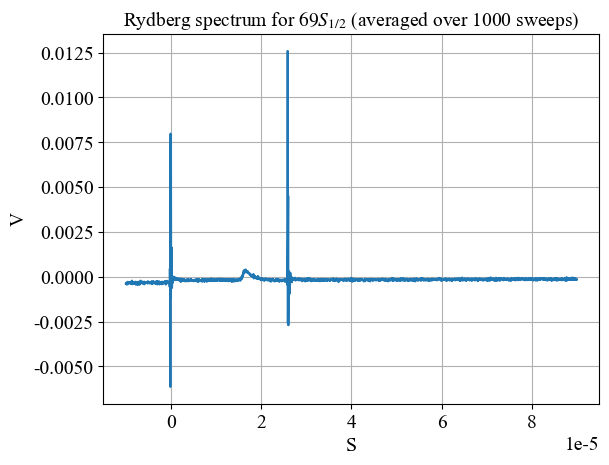

In [58]:
# collect trace for 69 S 1/2, averaging over 1000 scans (also include counting gate)
t_69s, v_69s, info = lecroy.read_waveform("TA")
t_gate, v_gate, info = lecroy.read_waveform("C3")

plt.figure(1)
plt.plot(t_69s, v_69s)
plt.xlabel(info["horizontal_unit"] or "s")
plt.ylabel(info["vertical_unit"] or "V")
plt.title("Rydberg spectrum for $69 S_{1/2}$ (averaged over 1000 sweeps)")
plt.grid(True)
plt.show()

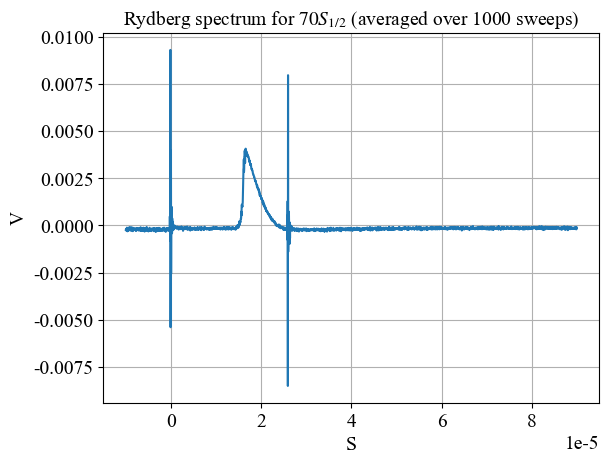

In [21]:
# collect trace for 70 S 1/2, averaging over 1000 scans (also include counting gate)
t_70s, v_70s, info = lecroy.read_waveform("TA")
t_gate, v_gate, info = lecroy.read_waveform("C3")

plt.figure(2)
plt.plot(t_70s, v_70s)
plt.xlabel(info["horizontal_unit"] or "s")
plt.ylabel(info["vertical_unit"] or "V")
plt.title("Rydberg spectrum for $70 S_{1/2}$ (averaged over 1000 sweeps)")
plt.grid(True)
plt.show()

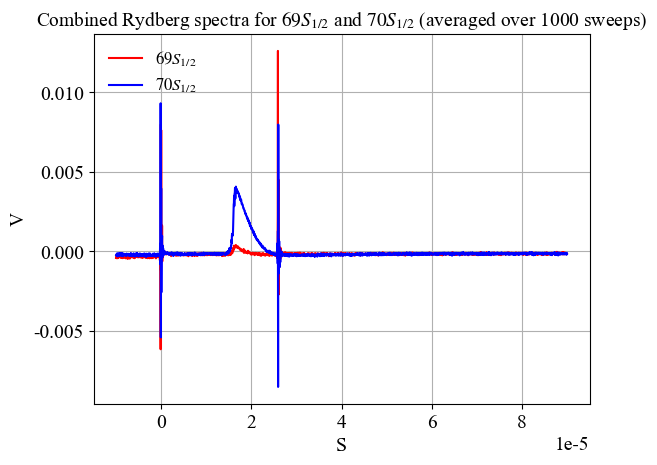

In [60]:
# plot both spectra together, referenced to the gate pulse
plt.figure(3)
plt.plot(t_69s, v_69s, 'r', label = "$69 S_{1/2}$")
plt.plot(t_70s, v_70s, 'b', label = "$70 S_{1/2}$")
#plt.plot(t_gate, v_gate, 'k--', label = "Counting gate")
plt.xlabel(info["horizontal_unit"] or "s")
plt.ylabel(info["vertical_unit"] or "V")
plt.title("Combined Rydberg spectra for $69 S_{1/2}$ and $70 S_{1/2}$ (averaged over 1000 sweeps)")
plt.legend(loc = "upper left")
plt.grid(True)
plt.show()

### Shut down instrumentation

In [ ]:
# reset voltages to zero
vset = np.array([0.0,0.0,0.0])
mcbox.set_voltage_Nchan(channels = [0,1,6,7,10,11], voltages = [0,-vset[2],vset[1],-vset[1],vset[0],-vset[0]], bipolar = True)

In [ ]:
# save current stepper motor position
weeder.save(header = "A", query = True)

In [ ]:
# OPTIONAL: disables pulses from BNC box (can also be done by pressing RUN/STOP button or individual channel buttons on device)
bnc575.disable_all()

In [ ]:
# OPTIONAL: disarms the pulse generator (can also be done by pressing RUN/STOP button on device)
bnc575.disarm_all()

In [ ]:
# disconnect from pulse generator
bnc575.pyvisa.close()

In [ ]:
# disconnect from oscillscope
lecroy.close()